#CV Lab 2

# Task 1

In [14]:
from google.colab import files
uploaded = files.upload()   # Upload Circle.jpg, Lana.jpg, Rectangle.jpg

# Image names
circle_img = cv2.imread("circle (1).png")
lana_img   = cv2.imread("input (1).jpg")
rect_img   = cv2.imread("rect (1).png")

print("Images loaded successfully.")

Images loaded successfully.


# Task 2

In [15]:
import cv2
import numpy as np
import random

def horizontal_flip(img):
    return cv2.flip(img, 1)

def rotate_random(img):
    angle = random.choice([90, 180, 270])
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
    return cv2.warpAffine(img, M, (w, h))

def shear(img):
    h, w = img.shape[:2]
    shear_factor = random.uniform(0.15, 0.35)
    M = np.float32([[1, shear_factor, 0],
                    [0, 1, 0]])
    new_w = int(w + shear_factor * h)
    return cv2.warpAffine(img, M, (new_w, h))

In [16]:
def augment(img):
    transformations = [horizontal_flip, rotate_random, shear]
    random.shuffle(transformations)  # Random order each time

    aug = img.copy()
    for t in transformations:
        aug = t(aug)
    return aug

# Batch Processing

In [17]:
import os

images = {
    "Circle": circle_img,
    "Lana": lana_img,
    "Rectangle": rect_img
}

output_folder = "/content/augmented"
os.makedirs(output_folder, exist_ok=True)

N = 5   # number of augmentations per image

for name, img in images.items():
    for i in range(1, N+1):
        aug_img = augment(img)
        save_path = f"{output_folder}/{name}_aug{i}.jpg"
        cv2.imwrite(save_path, aug_img)

print("Batch processing complete!")

Batch processing complete!


# Visualization

In [18]:
def create_collage(img):
    # Generate 8 augmentations
    aug_list = [augment(img) for _ in range(8)]

    # Normalize all images to same size
    H, W = 300, 300
    orig_resized = cv2.resize(img, (W, H))
    aug_resized  = [cv2.resize(a, (W, H)) for a in aug_list]

    # Build 3×3 grid
    row1 = np.hstack([orig_resized, aug_resized[0], aug_resized[1]])
    row2 = np.hstack([aug_resized[2], aug_resized[3], aug_resized[4]])
    row3 = np.hstack([aug_resized[5], aug_resized[6], aug_resized[7]])

    collage = np.vstack([row1, row2, row3])
    return collage

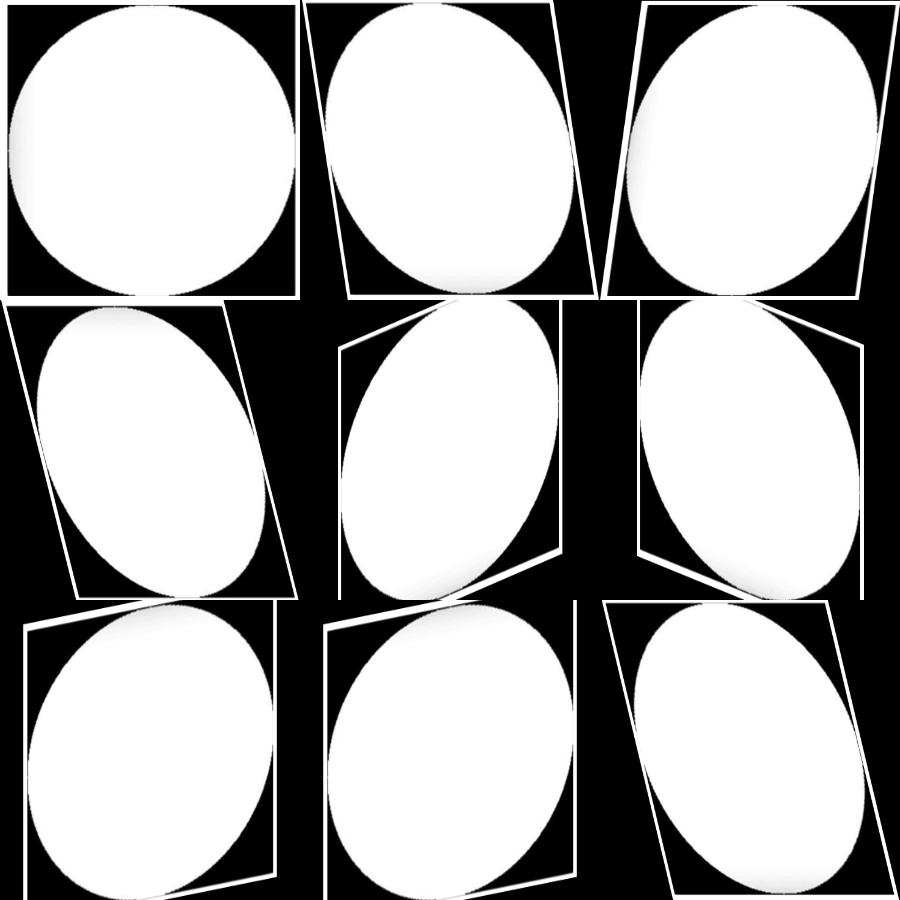

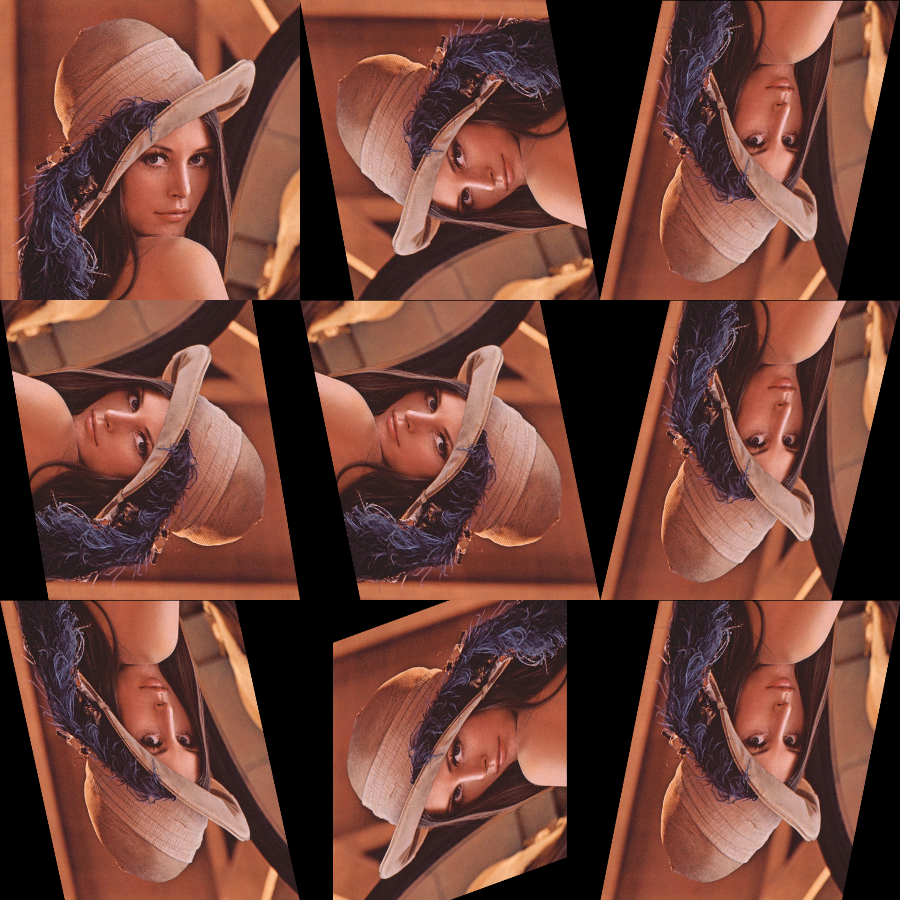

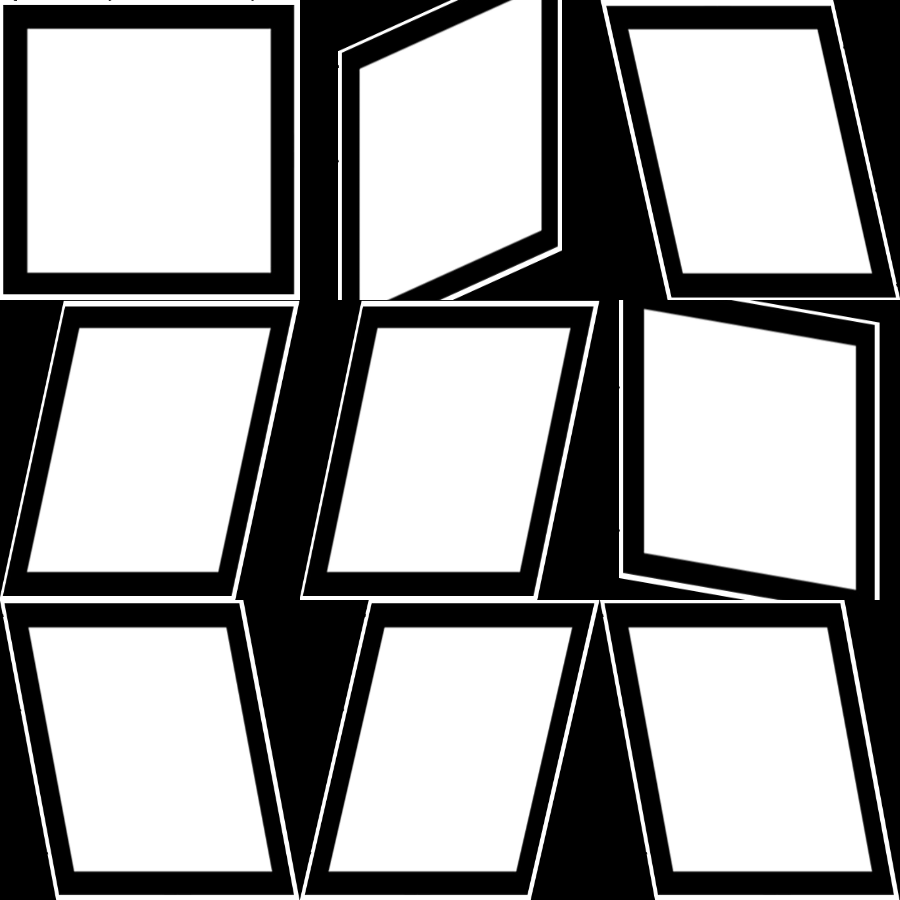

True

In [19]:
from google.colab.patches import cv2_imshow

circle_collage = create_collage(circle_img)
lana_collage   = create_collage(lana_img)
rect_collage   = create_collage(rect_img)

cv2_imshow(circle_collage)
cv2.imwrite("Circle_collage.jpg", circle_collage)

cv2_imshow(lana_collage)
cv2.imwrite("Lana_collage.jpg", lana_collage)

cv2_imshow(rect_collage)
cv2.imwrite("Rectangle_collage.jpg", rect_collage)